In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
PROJECT_DIR = Path.cwd().parent

DATA = PROJECT_DIR / "processed" / "cleaned_dataset.csv"

df = pd.read_csv(DATA)

print(df.shape)

df.head()

(104522, 39)


,week,measurement_site,latitude,longitude,vehicle_category,source_file,time,direction_1,direction_2,direction_3,direction_4,direction_5,direction_6,direction_7,direction_8,direction_9,direction_10,direction_11,direction_12,direction_13,direction_14,direction_15,direction_16,direction_17,direction_18,direction_19,direction_20,direction_21,direction_22,direction_23,direction_24,direction_25,direction_26,direction_27,direction_28,total_traffic,hour,minute,peak_period
0,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:00:00,5.0,43.0,9.0,17.0,0.0,0.0,74.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,52.0,0.0,43.0,0.0,0.0,26.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,274.0,0.0,0.0,Off Peak
1,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:15:00,4.0,31.0,15.0,14.0,0.0,0.0,64.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,46.0,0.0,31.0,0.0,0.0,29.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,238.0,0.0,15.0,Off Peak
2,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:30:00,5.0,35.0,7.0,23.0,0.0,0.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,42.0,0.0,35.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,252.0,0.0,30.0,Off Peak
3,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:45:00,4.0,36.0,4.0,15.0,0.0,0.0,59.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,40.0,0.0,36.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,217.0,0.0,45.0,Off Peak
4,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,01:00:00,6.0,15.0,7.0,15.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,22.0,0.0,15.0,0.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,151.0,1.0,0.0,Off Peak


In [4]:
import re

def extract_date(text):
    match = re.search(r'(\d{2})\.(\d{2})', str(text))
    if match:
        day = match.group(1)
        month = match.group(2)
        return f"2024-{month}-{day}"
    return None

df["date"] = df["week"].apply(extract_date)

df["date"] = pd.to_datetime(df["date"])

df[["week","date"]].head()

,week,date
0,DZwEI 30.09-07.10,2024-09-30
1,DZwEI 30.09-07.10,2024-09-30
2,DZwEI 30.09-07.10,2024-09-30
3,DZwEI 30.09-07.10,2024-09-30
4,DZwEI 30.09-07.10,2024-09-30


In [5]:
df["weekday"] = df["date"].dt.day_name()

df["weekday"].value_counts()

weekday
Monday     75344
Tuesday    29178
Name: count, dtype: int64

In [6]:
df["is_weekend"] = df["weekday"].isin(
    ["Saturday","Sunday"]
)

df[["weekday","is_weekend"]].head()

,weekday,is_weekend
0,Monday,False
1,Monday,False
2,Monday,False
3,Monday,False
4,Monday,False


In [7]:
weekday_avg = (

    df.groupby("weekday")["total_traffic"]

    .mean()

    .reindex(

        ["Monday","Tuesday","Wednesday","Thursday",

         "Friday","Saturday","Sunday"]

    )

)

weekday_avg

weekday
Monday       380.569495
Tuesday      156.589451
Wednesday           NaN
Thursday            NaN
Friday              NaN
Saturday            NaN
Sunday              NaN
Name: total_traffic, dtype: float64

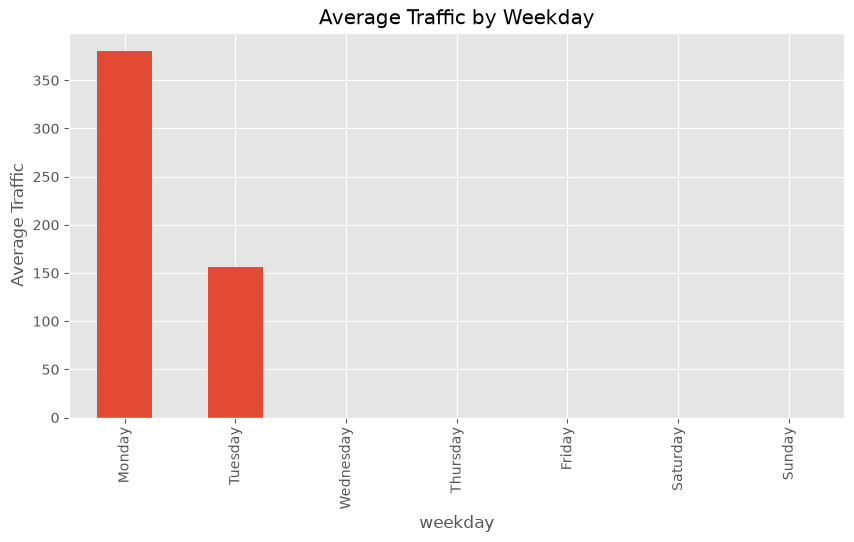

In [8]:
plt.figure(figsize=(10,5))

weekday_avg.plot(

    kind="bar"

)

plt.title("Average Traffic by Weekday")

plt.ylabel("Average Traffic")

plt.show()

In [9]:
heatmap = pd.pivot_table(

    df,

    values="total_traffic",

    index="weekday",

    columns="hour",

    aggfunc="mean"

)

heatmap = heatmap.reindex(

    ["Monday","Tuesday","Wednesday",

     "Thursday","Friday","Saturday","Sunday"]

)

heatmap

hour,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
weekday,,,,,,,,,,,,,,,,,,,,,,,,
Monday,150.307501,105.232242,78.570354,60.564991,60.731678,101.541413,178.000000,268.931702,332.957260,339.303477,342.831234,348.745753,369.517363,392.279934,421.206464,441.500572,470.201082,496.388115,475.689387,421.772668,365.651816,321.620813,297.016867,188.419223
Tuesday,77.895397,56.777545,43.707589,35.173666,30.539326,46.877243,78.968201,124.390098,157.754026,162.817335,181.829480,192.525375,204.006466,217.707138,230.378845,237.693165,243.806378,253.170694,252.419147,222.245629,184.675676,152.563849,139.487969,89.892347
Wednesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thursday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Friday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saturday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sunday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


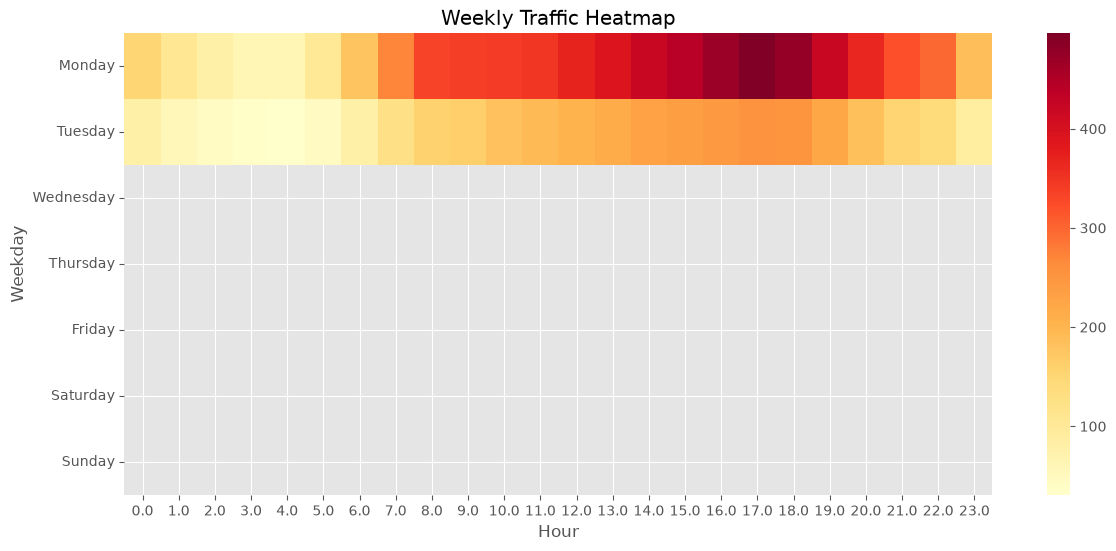

In [10]:
plt.figure(figsize=(14,6))

sns.heatmap(

    heatmap,

    cmap="YlOrRd",

    annot=False

)

plt.title("Weekly Traffic Heatmap")

plt.xlabel("Hour")

plt.ylabel("Weekday")

plt.show()

In [11]:
comparison = (

    df.groupby("is_weekend")["total_traffic"]

    .mean()

)

comparison

is_weekend
False    318.044
Name: total_traffic, dtype: float64

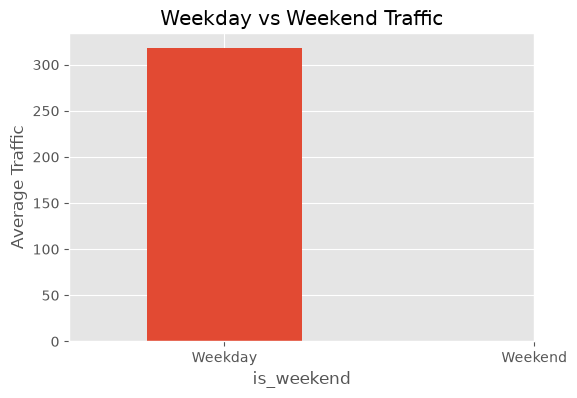

In [12]:
plt.figure(figsize=(6,4))

comparison.plot(

    kind="bar"

)

plt.xticks(

    [0,1],

    ["Weekday","Weekend"],

    rotation=0

)

plt.ylabel("Average Traffic")

plt.title("Weekday vs Weekend Traffic")

plt.show()

In [13]:
weekday_df = df[df["is_weekend"]==False]

weekday_heat = pd.pivot_table(

    weekday_df,

    values="total_traffic",

    index="weekday",

    columns="hour",

    aggfunc="mean"

)

weekday_heat = weekday_heat.reindex(

    ["Monday","Tuesday","Wednesday",

     "Thursday","Friday"]

)

weekday_heat

hour,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
weekday,,,,,,,,,,,,,,,,,,,,,,,,
Monday,150.307501,105.232242,78.570354,60.564991,60.731678,101.541413,178.000000,268.931702,332.957260,339.303477,342.831234,348.745753,369.517363,392.279934,421.206464,441.500572,470.201082,496.388115,475.689387,421.772668,365.651816,321.620813,297.016867,188.419223
Tuesday,77.895397,56.777545,43.707589,35.173666,30.539326,46.877243,78.968201,124.390098,157.754026,162.817335,181.829480,192.525375,204.006466,217.707138,230.378845,237.693165,243.806378,253.170694,252.419147,222.245629,184.675676,152.563849,139.487969,89.892347
Wednesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thursday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Friday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


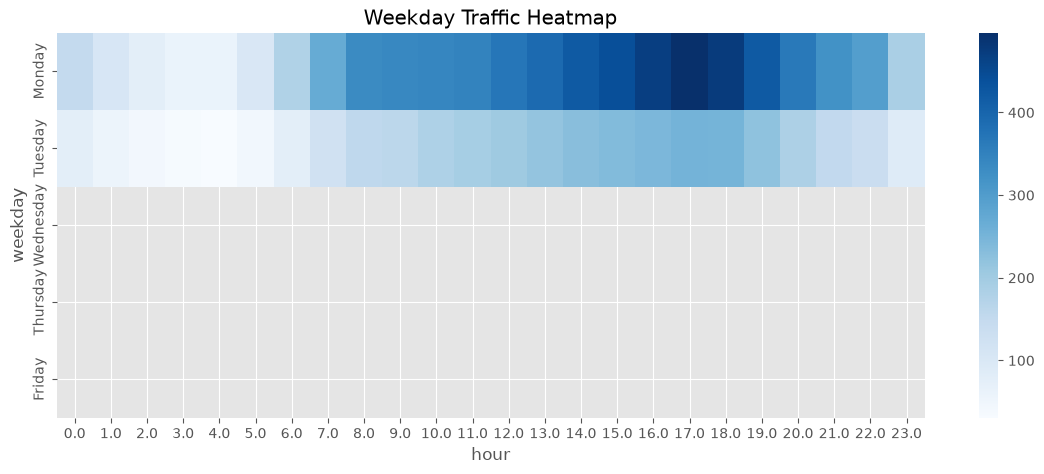

In [14]:
plt.figure(figsize=(14,5))

sns.heatmap(

    weekday_heat,

    cmap="Blues"

)

plt.title("Weekday Traffic Heatmap")

plt.show()

In [15]:
weekend_df = df[df["is_weekend"]==True]

weekend_heat = pd.pivot_table(

    weekend_df,

    values="total_traffic",

    index="weekday",

    columns="hour",

    aggfunc="mean"

)

weekend_heat

hour
weekday


In [17]:
top_hours = (

    df.groupby(["weekday","hour"])["total_traffic"]

    .mean()

    .sort_values(ascending=False)

    .head(20)

)

top_hours

weekday  hour
Monday   17.0    496.388115
         18.0    475.689387
         16.0    470.201082
         15.0    441.500572
         19.0    421.772668
         14.0    421.206464
         13.0    392.279934
         12.0    369.517363
         20.0    365.651816
         11.0    348.745753
         10.0    342.831234
         9.0     339.303477
         8.0     332.957260
         21.0    321.620813
         22.0    297.016867
         7.0     268.931702
Tuesday  17.0    253.170694
         18.0    252.419147
         16.0    243.806378
         15.0    237.693165
Name: total_traffic, dtype: float64

In [18]:
patterns = (

    df.groupby(

        ["weekday","peak_period"]

    )["total_traffic"]

    .mean()

    .unstack()

)

patterns

peak_period,Evening Peak,Midday,Morning Peak,Off Peak
weekday,,,,
Monday,470.344841,374.893644,282.513435,389.529474
Tuesday,246.599152,205.028542,132.885444,99.600152


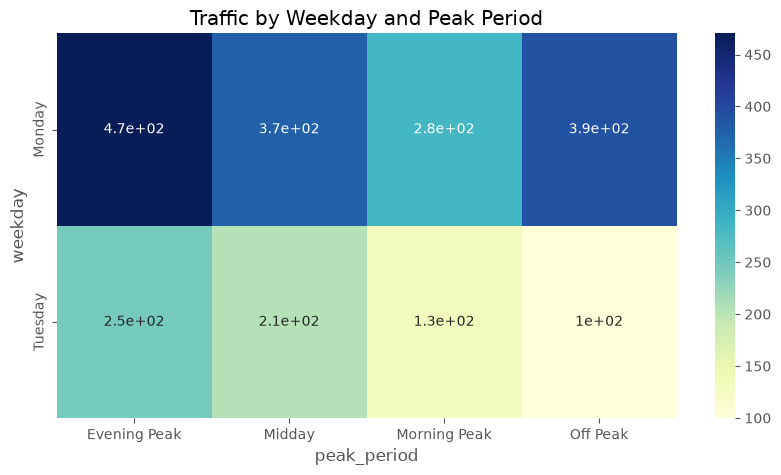

In [19]:
plt.figure(figsize=(10,5))

sns.heatmap(

    patterns,

    annot=True,

    cmap="YlGnBu"

)

plt.title("Traffic by Weekday and Peak Period")

plt.show()

In [20]:
print("="*60)

print("TASK 2 SUMMARY")

print("="*60)

print("Average weekday traffic")

print()

print(weekday_avg)

print()

print("Weekday vs Weekend")

print(comparison)

TASK 2 SUMMARY
Average weekday traffic

weekday
Monday       380.569495
Tuesday      156.589451
Wednesday           NaN
Thursday            NaN
Friday              NaN
Saturday            NaN
Sunday              NaN
Name: total_traffic, dtype: float64

Weekday vs Weekend
is_weekend
False    318.044
Name: total_traffic, dtype: float64
